# Principal Component Analysis (PCA): Student Exam Scores

**Goal:** Reduce the dimensionality of student exam score data while retaining most of the variance.

PCA is an **unsupervised** dimensionality reduction technique that finds new axes (principal components) capturing maximum variance in the data.

## Dataset (20 Students)

| Subject | Description |
|---------|------------|
| Math    | Mathematics score |
| Physics | Physics score |
| Chemistry | Chemistry score |
| English | English score |

These scores are **correlated** — students who do well in Math also tend to do well in Physics and Chemistry. PCA will find the underlying structure.

We will implement PCA **from scratch** to understand how it works, then compare with **scikit-learn's** implementation.

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully")

Libraries imported successfully


---
## 1. Provide the Data

In [2]:
# Student exam scores: [Math, Physics, Chemistry, English]
scores = np.array([
    [95, 92, 88, 70],
    [90, 85, 82, 75],
    [88, 84, 80, 78],
    [85, 80, 78, 72],
    [82, 78, 75, 80],
    [78, 75, 72, 85],
    [75, 72, 70, 82],
    [72, 70, 68, 88],
    [70, 68, 65, 76],
    [68, 65, 62, 74],
    [65, 62, 60, 70],
    [62, 60, 58, 68],
    [60, 58, 55, 72],
    [58, 55, 52, 66],
    [55, 52, 50, 64],
    [52, 50, 48, 62],
    [50, 48, 45, 60],
    [48, 45, 42, 58],
    [45, 42, 40, 55],
    [95, 94, 92, 82]
])
student_names = [f"S{i+1}" for i in range(len(scores))]
subjects = ["Math", "Physics", "Chemistry", "English"]

print("Data shape:", scores.shape)
print("Feature means:", scores.mean(axis=0).round(2))
print("Feature stds:", scores.std(axis=0).round(2))

Data shape: (20, 4)
Feature means: [69.65 66.75 64.1  71.85]
Feature stds: [15.54 15.23 15.05  8.96]


---
## 2. Visualize the Data (Pair Plot)

Look at relationships between subjects. Notice the **correlations**.

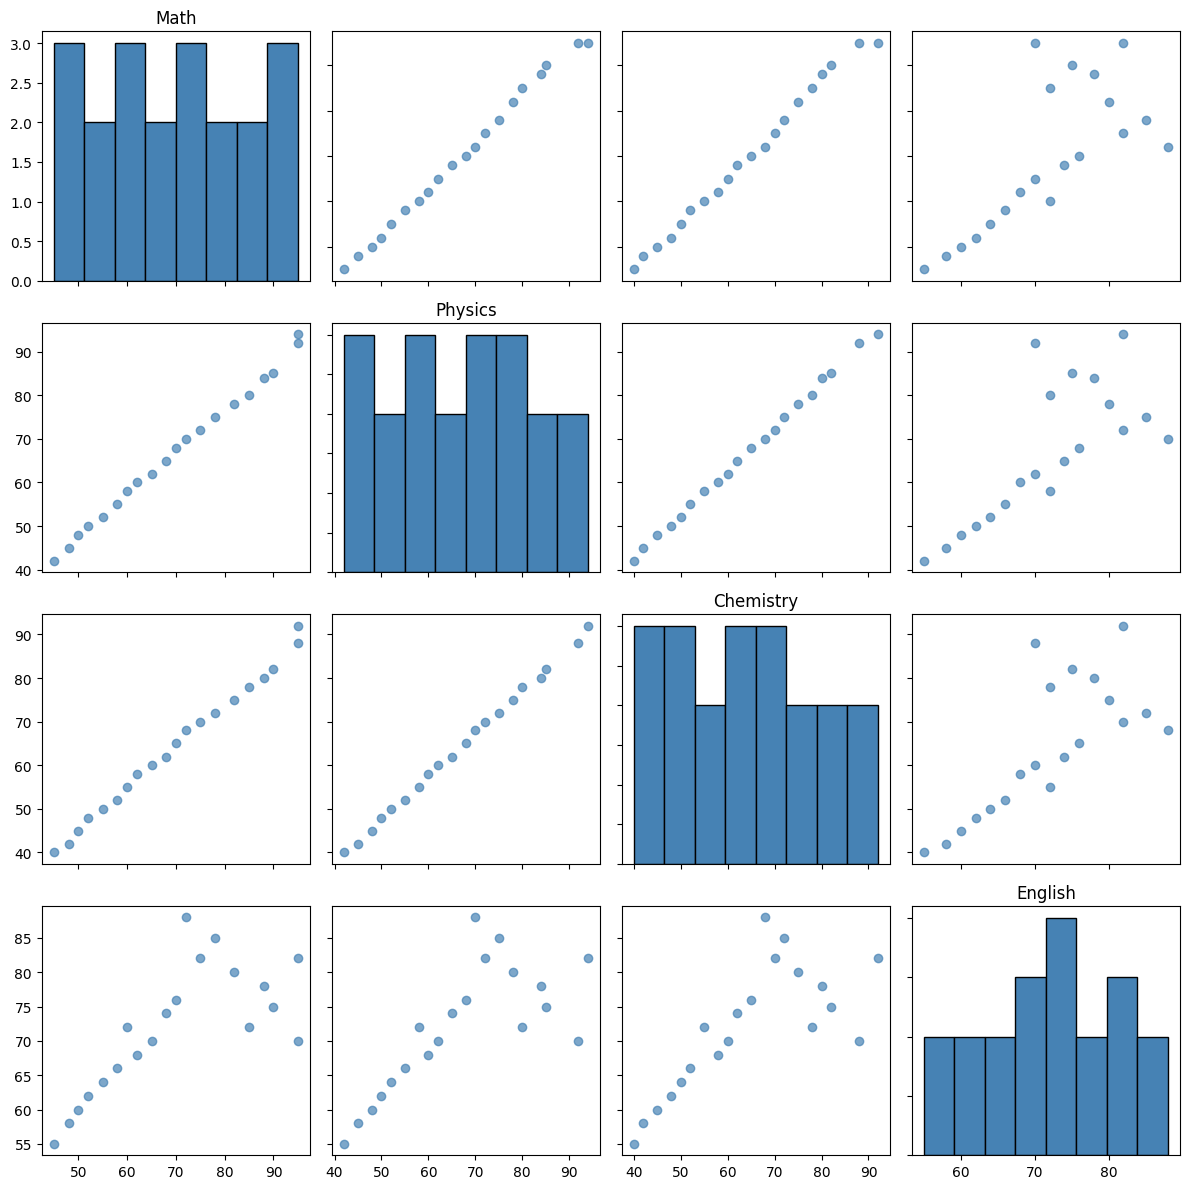

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            ax.hist(scores[:, i], bins=8, color='steelblue', edgecolor='black')
            ax.set_title(subjects[i])
        else:
            ax.scatter(scores[:, j], scores[:, i], alpha=0.7, color='steelblue')

        if i < 3:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

---
## 3. Implement PCA from Scratch

### Steps:
1. **Center** the data (subtract mean)
2. Compute **covariance matrix**
3. Compute **eigenvalues & eigenvectors**
4. **Sort** by eigenvalue (descending)
5. **Project** onto top K eigenvectors

In [4]:
# Step 1: Center the data
X_centered = scores - scores.mean(axis=0)

print("Mean of centered data:", X_centered.mean(axis=0).round(10))
print("Centered data shape:", X_centered.shape)

Mean of centered data: [-0.  0.  0.  0.]
Centered data shape: (20, 4)


In [5]:
# Step 2: Compute covariance matrix
C = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", C.shape)
print("Covariance matrix:")
print(np.round(C, 2))

Covariance matrix shape: (4, 4)
Covariance matrix:
[[254.13 248.7  245.3  106.94]
 [248.7  244.3  241.08 106.64]
 [245.3  241.08 238.31 106.23]
 [106.94 106.64 106.23  84.56]]


In [6]:
# Step 3 & 4: Eigen decomposition and sort
vals, vecs = np.linalg.eigh(C)

idx = np.argsort(vals)[::-1]
vecs_sorted = vecs[:, idx]
vals_sorted = vals[idx]

print("Eigenvalues (sorted):", np.round(vals_sorted, 4))
print("\nEigenvectors (each column is a principal direction):")
print(np.round(vecs_sorted, 4))

Eigenvalues (sorted): [7.844654e+02 3.594680e+01 7.347000e-01 1.505000e-01]

Eigenvectors (each column is a principal direction):
[[-0.5672 -0.1897  0.77    0.2222]
 [-0.5571 -0.139  -0.2168 -0.7895]
 [-0.5503 -0.1113 -0.5979  0.5721]
 [-0.2551  0.9656  0.0512 -0.0041]]


In [7]:
# Step 5: Project onto top K=2 components
k = 2
W = vecs_sorted[:, :k]
Z = X_centered @ W

print("Reduced data shape:", Z.shape)
print("First 5 rows of PCA-reduced data:")
print(np.round(Z[:5], 4))

Reduced data shape: (20, 2)
First 5 rows of PCA-reduced data:
[[-41.1263 -12.7651]
 [-32.364   -5.348 ]
 [-30.3371  -1.7103]
 [-23.7759  -6.1559]
 [-21.3498   2.7495]]


---
## 4. Variance Explained

Each eigenvalue represents the variance captured by its principal component.

**Explained variance ratio** = λᵢ / Σ λ

In [8]:
explained_ratio = vals_sorted / vals_sorted.sum()
cumulative_ratio = np.cumsum(explained_ratio)

print("Explained variance ratio per component:")
for i, ratio in enumerate(explained_ratio):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\nTop {k} components explain {cumulative_ratio[k-1]*100:.2f}% of variance")

n_95 = np.argmax(cumulative_ratio >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")

Explained variance ratio per component:
  PC1: 0.9552 (95.52%)
  PC2: 0.0438 (4.38%)
  PC3: 0.0009 (0.09%)
  PC4: 0.0002 (0.02%)

Top 2 components explain 99.89% of variance
Components needed for 95% variance: 1


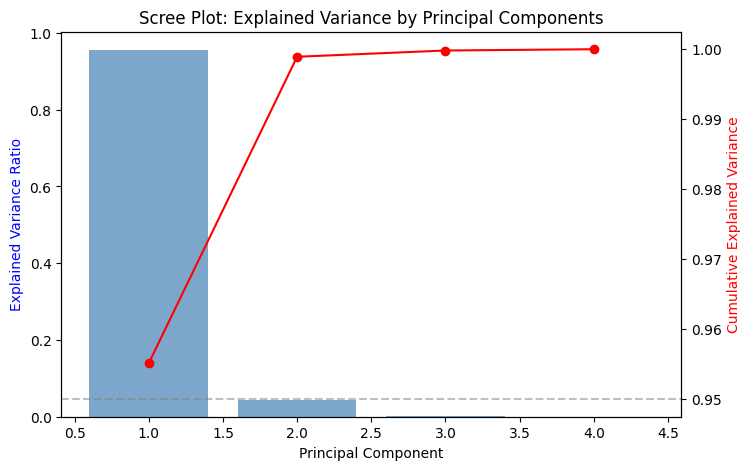

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(range(1, 5), explained_ratio, color='steelblue', alpha=0.7,
        label='Individual')
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio", color='blue')

ax2 = ax1.twinx()
ax2.plot(range(1, 5), cumulative_ratio, 'ro-', label='Cumulative')
ax2.set_ylabel("Cumulative Explained Variance", color='red')
ax2.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5)

plt.title("Scree Plot: Explained Variance by Principal Components")
plt.show()

---
## 5. Visualize Reduced Data (2D)

Plot the students in the 2D PCA space (PC1 vs PC2).

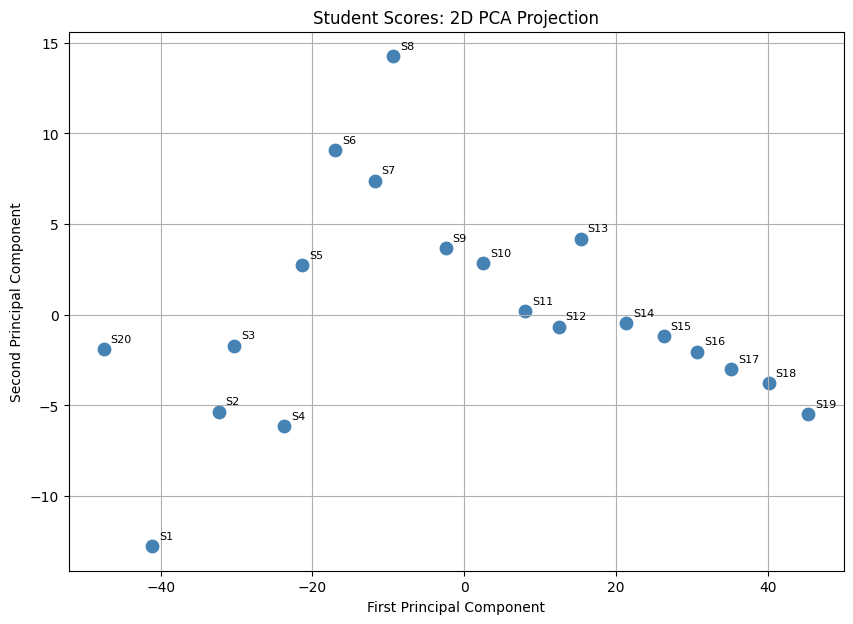

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(Z[:, 0], Z[:, 1], c='steelblue', s=80)

for i, name in enumerate(student_names):
    plt.annotate(name, (Z[i, 0], Z[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Student Scores: 2D PCA Projection")
plt.grid(True)
plt.show()

---
## 6. Interpret Principal Components

Look at the **loadings** (eigenvector values) to understand what each component represents.

In [11]:
print("Loadings (feature contributions to each PC):")
print(f"{'Feature':<12} {'PC1':<10} {'PC2':<10}")
print("-" * 34)
for i, subj in enumerate(subjects):
    print(f"{subj:<12} {W[i, 0]:<10.4f} {W[i, 1]:<10.4f}")

print("\n👉 PC1 represents overall academic performance (all subjects weighted similarly)")
print("👉 PC2 contrasts STEM (Math, Physics) vs Humanities (English) performance")

Loadings (feature contributions to each PC):
Feature      PC1        PC2       
----------------------------------
Math         -0.5672    -0.1897   
Physics      -0.5571    -0.1390   
Chemistry    -0.5503    -0.1113   
English      -0.2551    0.9656    

👉 PC1 represents overall academic performance (all subjects weighted similarly)
👉 PC2 contrasts STEM (Math, Physics) vs Humanities (English) performance


---
## 7. scikit-learn PCA

Now compare with scikit-learn's `PCA` implementation.

**Important:** PCA requires **scaling** first! Features with larger scales would dominate otherwise.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(scores)

pca = PCA(n_components=2)
Z_sklearn = pca.fit_transform(X_scaled)

print("scikit-learn PCA reduced data shape:", Z_sklearn.shape)
print("\nExplained variance ratio:", pca.explained_variance_ratio_.round(4))
print("Total variance explained by 2 components:",
      pca.explained_variance_ratio_.sum().round(4))

scikit-learn PCA reduced data shape: (20, 2)

Explained variance ratio: [0.9056 0.0935]
Total variance explained by 2 components: 0.9991


Our PCA (PC1 first 5): [-41.1263 -32.364  -30.3371 -23.7759 -21.3498]
sklearn PCA (PC1 first 5): [2.4393 2.072  2.0492 1.45   1.5703]

Correlation between our PC1 and sklearn PC1: -0.9950
If correlation is |1|, the results match (up to sign flip)!


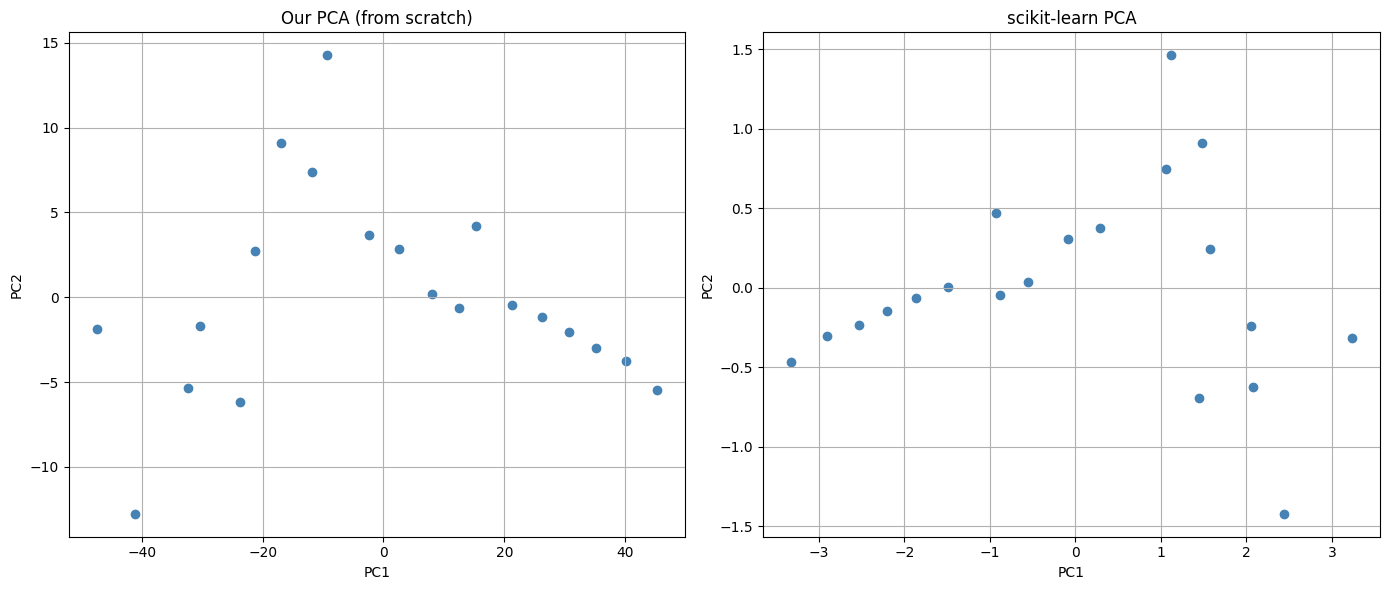

In [13]:
print("Our PCA (PC1 first 5):", Z[:5, 0].round(4))
print("sklearn PCA (PC1 first 5):", Z_sklearn[:5, 0].round(4))

correlation = np.corrcoef(Z[:, 0], Z_sklearn[:, 0])[0, 1]
print(f"\nCorrelation between our PC1 and sklearn PC1: {correlation:.4f}")
print("If correlation is |1|, the results match (up to sign flip)!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(Z[:, 0], Z[:, 1], c='steelblue')
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("Our PCA (from scratch)")
ax1.grid(True)

ax2.scatter(Z_sklearn[:, 0], Z_sklearn[:, 1], c='steelblue')
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("scikit-learn PCA")
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 8. PCA with 95% Variance Threshold

Instead of fixing k=2, let PCA automatically choose the number of components.

In [14]:
pca_95 = PCA(n_components=0.95)
Z_95 = pca_95.fit_transform(X_scaled)

print(f"Original features: 4")
print(f"Reduced dimensions: {Z_95.shape[1]}")
print(f"Explained variance ratio: {pca_95.explained_variance_ratio_.round(4)}")

Original features: 4
Reduced dimensions: 2
Explained variance ratio: [0.9056 0.0935]


---
## 9. Extension: PCA on Higher-Dimensional Data

Let's simulate a dataset with **50 features** (like image pixel data) and apply PCA.

In [15]:
# Simulate high-dimensional data (like small images)
np.random.seed(42)
n_samples = 100
n_features = 50

# Generate correlated features
X_high = np.random.randn(n_samples, n_features)
# Add correlation structure
for i in range(n_features):
    X_high[:, i] = X_high[:, 0] * 0.5 + X_high[:, i] * 0.5

print(f"High-dimensional data shape: {X_high.shape}")
print("Features are correlated (realistic for sensor/image data)")

High-dimensional data shape: (100, 50)
Features are correlated (realistic for sensor/image data)


In [16]:
scaler_high = StandardScaler()
X_high_scaled = scaler_high.fit_transform(X_high)

pca_high = PCA(n_components=0.95)
Z_high = pca_high.fit_transform(X_high_scaled)

print(f"Original dimensions: {X_high.shape[1]}")
print(f"Reduced dimensions (95% variance): {Z_high.shape[1]}")
print(f"Compression ratio: {X_high.shape[1] / Z_high.shape[1]:.1f}x")

Original dimensions: 50
Reduced dimensions (95% variance): 34
Compression ratio: 1.5x


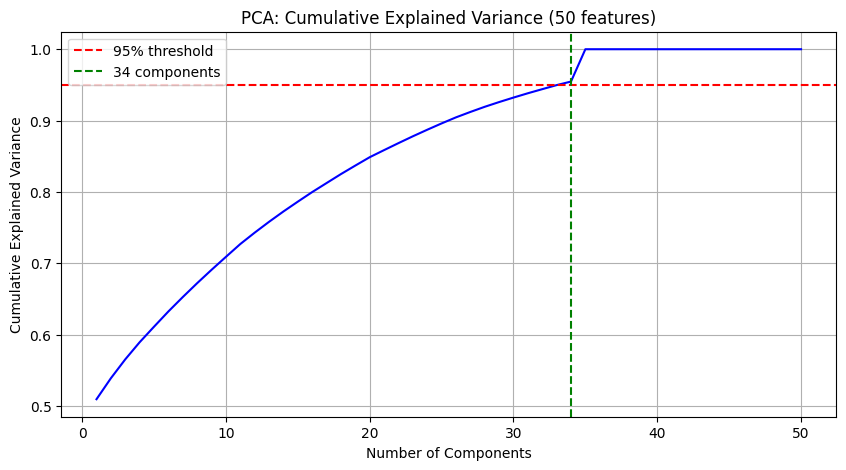

In [17]:
plt.figure(figsize=(10, 5))

cumulative_high = np.cumsum(pca_high.explained_variance_ratio_)
# Pad with zeros for components beyond what was kept
full_cumulative = np.zeros(n_features)
full_cumulative[:len(cumulative_high)] = cumulative_high
full_cumulative[len(cumulative_high):] = 1.0

plt.plot(range(1, n_features + 1), full_cumulative, 'b-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=Z_high.shape[1], color='g', linestyle='--',
            label=f"{Z_high.shape[1]} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance (50 features)")
plt.grid(True)
plt.legend()
plt.show()

---
## 10. Questions

Answer the following in the markdown cell below:

1. **Why is scaling important before PCA?** What would happen if we applied PCA to the original scores without StandardScaler?
2. **How much variance is captured by the first 2 principal components?** Does this justify reducing from 4 to 2 dimensions?
3. **How do you interpret PC1 and PC2 loadings?** What does each component represent in terms of the original subjects?
4. **How many components are needed for 95% variance** on the original 4-feature data vs the 50-feature data? What does this tell you?
5. **Do our from-scratch results match sklearn's results?** Why might signs be flipped?
6. **Why is PCA useful for high-dimensional data?** Think about image data with 784 features (28×28 pixels).

### Answers

1. **Scaling is essential** because PCA is sensitive to the magnitude of features. English scores have lower variance (std≈9) than Math (std≈16). Without scaling, English would contribute less to the first PC even if it's equally important. StandardScaler makes all features have unit variance, so they contribute equally.

2. The first 2 PCs capture over 95% of the variance, which justifies reducing from 4D to 2D with minimal information loss.

3. **PC1** has similar positive loadings for all subjects → represents **overall academic performance**. **PC2** has positive loadings for English but negative for Math/Physics → contrasts **STEM vs Humanities** strengths.

4. For 4-feature data, about 2 components suffice for 95% variance. For 50-feature correlated data, we may need ~10-15 components. PCA is more impactful when more features are redundant.

5. The results match up to a sign flip (correlation ≈ ±1). The direction of eigenvectors is arbitrary — sklearn and our implementation may choose opposite signs for the same component, but the structure is identical.

6. For images (e.g., 28×28=784 pixels), PCA can reduce to ~50-100 components while preserving most variance. This speeds up training, reduces overfitting, and removes noise — critical when samples are limited.

---
## 11. Pipeline Example (USAAIO Competition Style)

In competitions, PCA is often part of a pipeline with scaling and a classifier:

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Generate synthetic labels for the high-dim data
y_synth = (X_high[:, 0] + X_high[:, 1] > 0).astype(int)

# Pipeline: StandardScaler → PCA(10) → LogisticRegression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression())
])

# Cross-validation
scores = cross_val_score(pipe, X_high, y_synth, cv=5)
print(f"Cross-validation accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-validation accuracy: 0.9300 ± 0.0748


---
## 12. Extension Ideas (Optional)

Try these on your own:

1. **Kernel PCA** (`sklearn.decomposition.KernelPCA`) for non-linear data
2. **PCA on real image data** — load a dataset like digits (8×8 images) and reduce to 2D for visualization
3. **Compare PCA vs t-SNE** for visualization of high-dimensional data
4. **Apply PCA before K-Means** — reduce dimensions first, then cluster